In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df.shape)

(7043, 21)


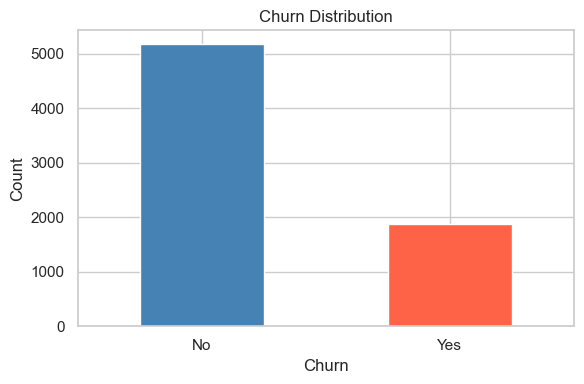

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], ax=ax)
ax.set_title('Churn Distribution')
ax.set_xlabel('Churn')
ax.set_ylabel('Count')
ax.set_xticklabels(['No', 'Yes'], rotation=0)
plt.tight_layout()
plt.savefig('../data/churn_distribution.png')
plt.show()

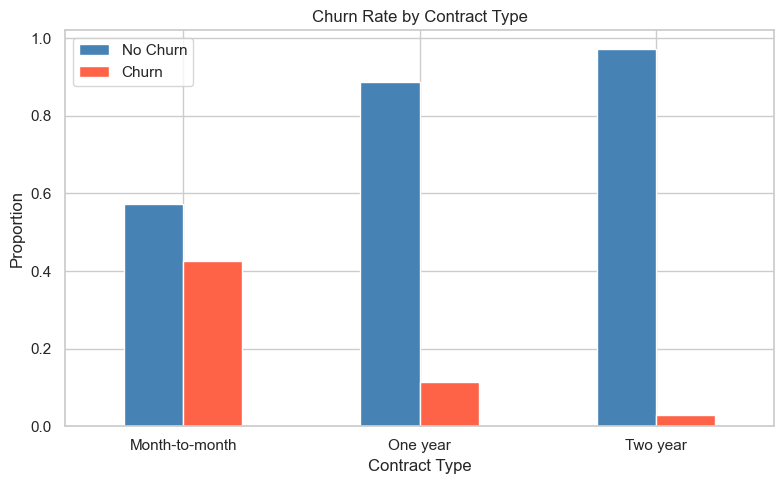

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
pd.crosstab(df['Contract'], df['Churn'], normalize='index').plot(
    kind='bar', color=['steelblue', 'tomato'], ax=ax
)
ax.set_title('Churn Rate by Contract Type')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Proportion')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(['No Churn', 'Churn'])
plt.tight_layout()
plt.savefig('../data/churn_by_contract.png')
plt.show()

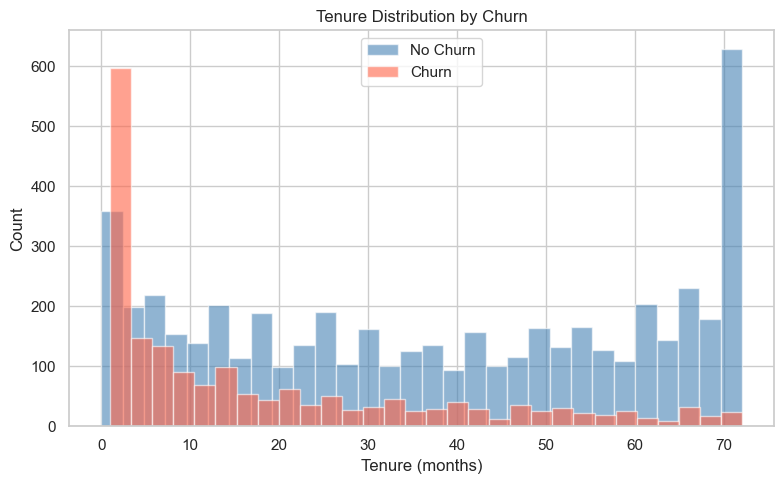

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
df[df['Churn'] == 'No']['tenure'].hist(bins=30, alpha=0.6, color='steelblue', label='No Churn', ax=ax)
df[df['Churn'] == 'Yes']['tenure'].hist(bins=30, alpha=0.6, color='tomato', label='Churn', ax=ax)
ax.set_title('Tenure Distribution by Churn')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../data/tenure_by_churn.png')
plt.show()

C:\Users\praja\AppData\Local\Temp\ipykernel_14476\4155367472.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=['steelblue', 'tomato'], ax=ax)


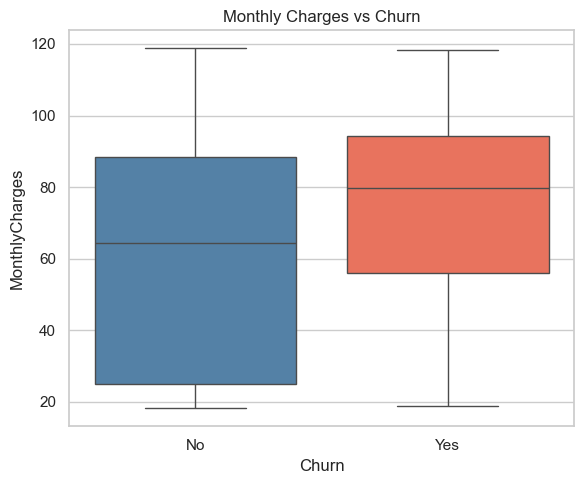

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=['steelblue', 'tomato'], ax=ax)
ax.set_title('Monthly Charges vs Churn')
plt.tight_layout()
plt.savefig('../data/monthly_charges_churn.png')
plt.show()

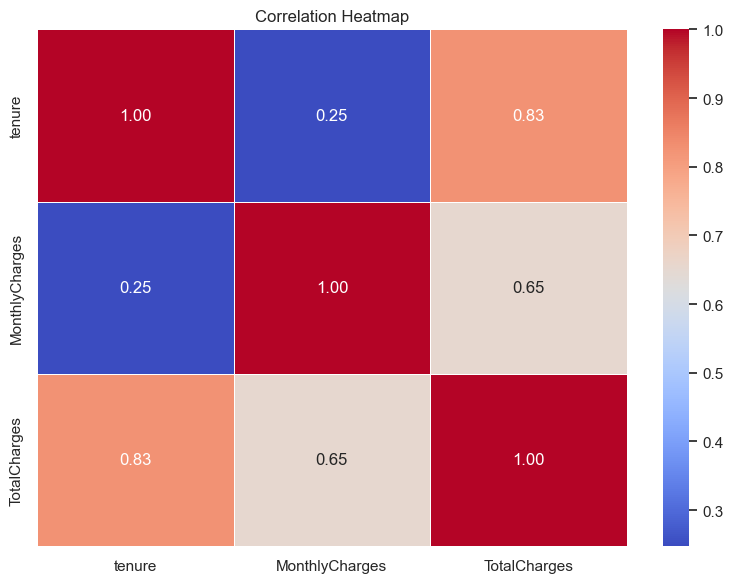

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()

sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',

linewidths=0.5, ax=ax)

ax.set_title('Correlation Heatmap')

plt.tight_layout()

plt.savefig('../data/correlation_heatmap.png')

plt.show()

## 🔍 EDA Key Findings

1. **Contract type is the strongest churn predictor** — Month-to-month customers churn at ~43%, vs ~11% for one-year and ~3% for two-year contracts.
2. **New customers churn most** — Tenure histogram shows churn spikes heavily in the first 1–12 months.
3. **Higher charges = higher churn** — Churned customers pay significantly higher monthly charges on average.
4. **TotalCharges and tenure are highly correlated** (expected — longer tenure = more total payments).
5. **Target for model** — Contract type, tenure, and MonthlyCharges will likely be the most important features.